In [27]:
import scipy.io 
import numpy as np
import sympy as sp
import numpy.linalg as linal
from scipy.stats.distributions import chi2
import matplotlib.pyplot as plt
import pandas as pd

In [9]:
data = scipy.io.loadmat('steamdata.mat')
mean_shift = lambda x : x - x.mean(axis=0)

1 2 4 -3
7 8 -6 -9 -5
5 -1 -10
10 11 -12
3 13 -11 -14 -15 -16 -17
6 -2 -13
14 18 -19 -21 -7 -20
22 15 -24 -23 -18
12 16 -22 -25
27 23 19 -26
20 26 28 -8

In [10]:
Atrue = np.zeros((11,28))
im    = np.array([ [1,2,-3,4], \
                   [7,8,-6,-9,-5], \
                   [5,-1,-10], \
                   [10,11,-12],\
                   [3,13,-11,-14,-15,-16,-17],\
                   [6,-2,-13],\
                   [14,18,-19,-21,-7,-20],\
                   [22,15,-24,-23,-18],\
                   [12,16,-22,-25],\
                   [27,23,19,-26],\
                   [20,26,28,-8] ])
for i in range(11) : 
    # x = input("Enter value : ").split(' ')
    # print(x)
    for j in im[i]: 
        if j > 0 : 
            Atrue[i,j - 1] = 1
        elif j < 0 : 
            Atrue[i,-j - 1] = -1

/tmp/ipykernel_22627/1537030067.py:2: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  im    = np.array([ [1,2,-3,4], \


In [11]:
data['Ftruer']@Atrue.T < 1e-13

array([[ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       ...,
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True],
       [ True,  True,  True, ...,  True,  True,  True]])

In [12]:
np.set_printoptions(suppress=True)

Z         = data['Fmeasr']
Zm        = mean_shift(Z)
N, p      = np.shape(Z)
m         = 11
L         = np.diag(np.ones(p))

std_p    = np.empty((28 ,1))

for i in range(10) : 
    # COMPUTE A
    scale   = np.linalg.inv(L.T)
    Zs      = Zm@scale/np.sqrt(N)
    u, s, v = np.linalg.svd(Zs)
    evals   = s**2
    As      = v [-m:,:]
    A       = As@(scale.T)

    # COMPUTE L
    R       = Zm@(A.T)
    G       = np.kron(A, A) [:,::(p+1)]
    V       = R.T @ R / N
    vecV    = V.T.reshape((m*m, 1))

    var     = np.abs(linal.inv(G.T@G)@G.T@vecV)
    L       = np.diag(np.sqrt(var).T[0])
    
    std_p    = np.append(std_p   , np.sqrt(var), axis=1)

std_p    = std_p    [:, 1:]

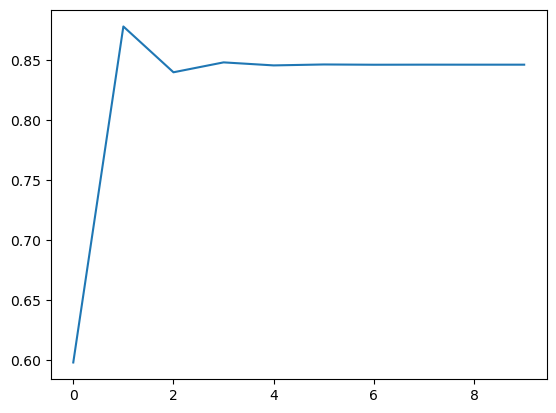

In [13]:
plt.plot(std_p[1])

In [14]:
d = p-1
Y = Zm@np.linalg.inv(L.T)

evals = np.sort(np.linalg.eig
                ( Y.T@Y / N) [0]).real [::-1]
while d > 1 : 
    n_dash = N - (2*p+11)/6
    l_dash = evals[ p-d : ].sum()/d 
    tau    = n_dash * ( d * np.log(l_dash) - np.log(evals[ p-d : ]).sum())
    fdom   = 0.5*(d+2)*(d-1)
    chi    = chi2.ppf(0.95, df=fdom)

    print(f"{d} \t||\t  TEST STATISTIC : {np.round(tau,3)} \t | \t CHI2 : {np.round(chi,3)}")

    if (tau <= chi) : 
        print()
        print("Number of Constraints :", d)
        break 
    else : 
        d = d - 1 

27 	||	  TEST STATISTIC : 51145.098 	 | 	 CHI2 : 423.274
26 	||	  TEST STATISTIC : 44961.746 	 | 	 CHI2 : 394.626
25 	||	  TEST STATISTIC : 38434.009 	 | 	 CHI2 : 366.977
24 	||	  TEST STATISTIC : 29471.0 	 | 	 CHI2 : 340.328
23 	||	  TEST STATISTIC : 26472.356 	 | 	 CHI2 : 314.678
22 	||	  TEST STATISTIC : 23328.502 	 | 	 CHI2 : 290.028
21 	||	  TEST STATISTIC : 20757.091 	 | 	 CHI2 : 266.378
20 	||	  TEST STATISTIC : 17464.69 	 | 	 CHI2 : 243.727
19 	||	  TEST STATISTIC : 14754.087 	 | 	 CHI2 : 222.076
18 	||	  TEST STATISTIC : 11360.904 	 | 	 CHI2 : 201.423
17 	||	  TEST STATISTIC : 9042.111 	 | 	 CHI2 : 181.77
16 	||	  TEST STATISTIC : 6351.133 	 | 	 CHI2 : 163.116
15 	||	  TEST STATISTIC : 4404.365 	 | 	 CHI2 : 145.461
14 	||	  TEST STATISTIC : 2454.584 	 | 	 CHI2 : 128.804
13 	||	  TEST STATISTIC : 1381.162 	 | 	 CHI2 : 113.145
12 	||	  TEST STATISTIC : 677.345 	 | 	 CHI2 : 98.484
11 	||	  TEST STATISTIC : 101.227 	 | 	 CHI2 : 84.821
10 	||	  TEST STATISTIC : 70.667 	 | 	 CHI2 : 

In [15]:
evals

array([5767.68727079,  393.08980266,  292.93720567,  248.42642311,
         80.6143125 ,   67.2138753 ,   48.04574569,   44.88881426,
         31.22555319,   27.91786065,   17.03278771,   14.58631522,
          9.40656035,    7.47210254,    4.45167307,    3.16245502,
          2.55247558,    1.19763155,    1.10448416,    1.05365857,
          1.00197426,    0.97525554,    0.94691781,    0.93667117,
          0.89666733,    0.86691056,    0.81089426,    0.71585171])

In [16]:
U,S,V = linal.svd(Y/np.sqrt(N))
Acons = V[-11:,:]

In [2]:
from itertools import combinations

In [18]:
comb = list(combinations([i for i in range(28)],11))

In [19]:
val = 1000
index = 0 

for i in range(len(comb)) :
    Ad = Acons[:,comb[i]]
    # print(f"Condition Number of Ad : {linal.cond(Ad)} \t|\t combination index : {i}")
    test = linal.cond(Ad)

    if test < val : 
        val = test
        index = i

KeyboardInterrupt: 

In [20]:
len(comb)

21474180

In [25]:
comb[index]

(2, 3, 4, 5, 7, 11, 12, 13, 14, 24, 25)

In [31]:
df = pd.DataFrame(data['Fmissing'])

In [52]:
df_filled = df.fillna(df.mean(axis=0))
df_ms     = df_filled - df_filled.mean()